<a href="https://colab.research.google.com/github/Jmontoyaor/SignalsandSystems-/blob/main/TALLER_2_PARTE_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Demuestre si los siguientes sistemas de la forma
son sistemas lineales e invariantes en el tiempo (SLIT) (simule los sistemas en Python):


$$y[n] = x[n]/3 + 2x[n-1] - y[n-1]$$
$$y[n] = \sum_{k=-\infty}^{n} x^2[k]$$
$$y[n] = \text{median}(x[n])$$
$$y(t) = Ax(t) + B; \quad A, B \in \mathbb{R}$$

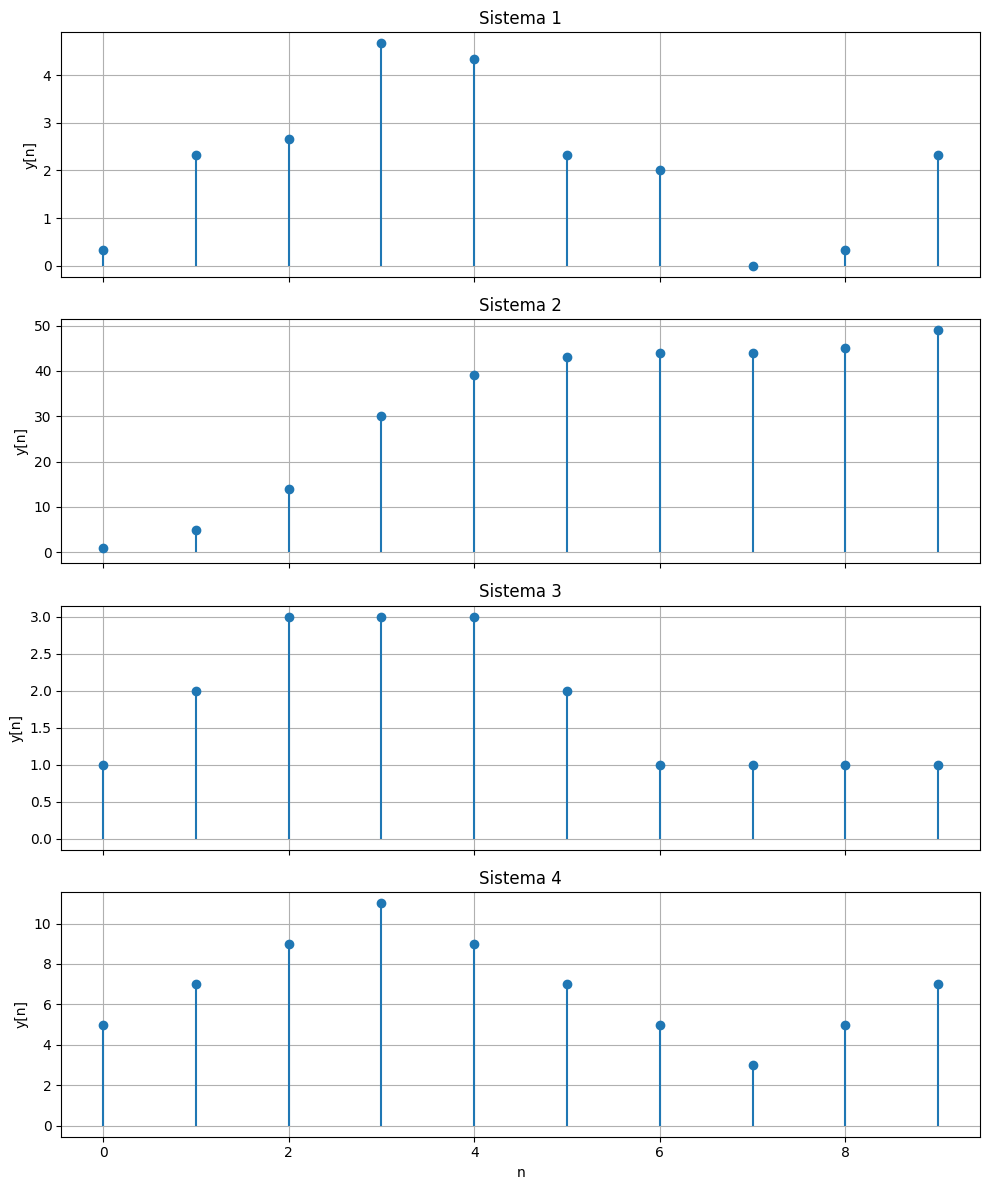

In [13]:
# Reimportar librerías y definir los sistemas
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import medfilt

# Señal de entrada
n = np.arange(0, 10)
x = np.array([1, 2, 3, 4, 3, 2, 1, 0, 1, 2])

# -------------------------
# Sistema 1:
# y[n] = x[n]/3 + 2x[n-1] - y[n-1]
# -------------------------
y1 = np.zeros_like(x, dtype=float)
for i in range(len(x)):
    x_n = x[i]
    x_n1 = x[i-1] if i-1 >= 0 else 0
    y_n1 = y1[i-1] if i-1 >= 0 else 0
    y1[i] = x_n / 3 + 2 * x_n1 - y_n1

# -------------------------
# Sistema 2:
# y[n] = sum_{k=-inf}^{n} x[k]^2  → acumulador cuadrático
# -------------------------
y2 = np.cumsum(x**2)

# -------------------------
# Sistema 3:
# y[n] = median(x[n]) sobre ventana de tamaño 3
# -------------------------
y3 = medfilt(x, kernel_size=3)

# -------------------------
# Sistema 4:
# y(t) = A * x(t) + B, A=2, B=3
# -------------------------
A, B = 2, 3
y4 = A * x + B

# -------------------------
# Agrupar resultados
# -------------------------
results = {
    "Sistema 1": y1,
    "Sistema 2": y2,
    "Sistema 3": y3,
    "Sistema 4": y4
}

# -------------------------
# Graficar los resultados
# -------------------------
fig, axs = plt.subplots(4, 1, figsize=(10, 12), sharex=True)

for i, (title, y) in enumerate(results.items()):
    axs[i].stem(n, y, basefmt=" ")  # sin use_line_collection
    axs[i].set_title(title)
    axs[i].set_ylabel("y[n]")
    axs[i].grid(True)

axs[-1].set_xlabel("n")
plt.tight_layout()
plt.show()



Hallar la salida $y[n]$ de un SLIT ante la entrada

$$x[n]={−15, 5, −3†, 0, 5, 7, −1}$$,
con respuesta al impulso

$$h[n]={1, −2, 0†, 1, −2}$$
donde $n∈{0, ±1, ±2, . . . , ±N} $yn=0 para $x[n]$
†
- Nota: Utilizar metodo gr  ́ afico para encon-  
trar la salida y comprobar con simulacion en Python. Ver  ́cuaderno Convolucion discreta. Repita el proceso para el sistema con respuesta al escalon ́{−1, 6, −10, 3†, 1, −10, 2, 5}


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from ipywidgets import interact
%matplotlib inline

In [15]:
# BLOQUE B: Definición de señales de entrada y respuesta
entrada = np.array([-15, 5, -3, 0, 5, 7, -1]).reshape(-1, 1)   # n = 0 en índice 2
respuesta_impulso = np.array([1, -2, 0, 1, -2]).reshape(-1, 1) # n = 0 en índice 2


In [16]:

def convolucion_manual(h, x):
    N_x = len(x)
    N_h = len(h)
    N_total = N_x + N_h - 1
    salida = np.zeros(N_total)
    desplazamientos = np.zeros((N_h, N_total))

    x_invertida = x[::-1].flatten()

    for n in range(N_total):
        temp = np.zeros(N_h)
        for k in range(N_h):
            if 0 <= n - k < N_x:
                temp[k] = x_invertida[n - k]
        desplazamientos[:, n] = temp
        salida[n] = np.dot(temp, h.flatten())

    return desplazamientos, salida, h

def graficar_convolucion(n, x_shifted, y_total, h):
    plt.figure(figsize=(9, 4))
    plt.stem(x_shifted[:, n], linefmt='b-', markerfmt='bo', label='x reflejada y desplazada')
    plt.stem(h, linefmt='g-', markerfmt='go', label='h fija')
    plt.stem(y_total[:n+1], linefmt='r-', markerfmt='rs', label='y acumulada')
    plt.title('1')
    plt.xlabel('Índice n')
    plt.ylabel('Amplitud')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# BLOQUE E: Ejecutar convolución e interactuar visualmente
matriz_x, salida_y, h_utilizada = convolucion_manual(respuesta_impulso, entrada)

@interact(paso=(0, len(salida_y)-1))
def visualizar(paso=0):
    graficar_convolucion(paso, matriz_x, salida_y, h_utilizada)



interactive(children=(IntSlider(value=0, description='paso', max=10), Output()), _dom_classes=('widget-interac…

In [17]:
pos_cero_x = 2
pos_cero_h = 2
pos_cero_y = pos_cero_x + pos_cero_h
eje_y = np.arange(-pos_cero_y, len(salida_y) - pos_cero_y)

print("Resultado final de y[n]:")
for n_idx, valor in zip(eje_y, salida_y):
    print(f"n = {n_idx:>2} --> y[n] = {valor:>6.1f}")

Resultado final de y[n]:
n = -4 --> y[n] =   -1.0
n = -3 --> y[n] =    9.0
n = -2 --> y[n] =   -9.0
n = -1 --> y[n] =  -11.0
n =  0 --> y[n] =    6.0
n =  1 --> y[n] =    2.0
n =  2 --> y[n] =  -35.0
n =  3 --> y[n] =   27.0
n =  4 --> y[n] =   11.0
n =  5 --> y[n] =  -25.0
n =  6 --> y[n] =   30.0


In [18]:
# BLOQUE G: Nueva respuesta escalón
respuesta_escalon = np.array([-1, 6, -10, 3, 1, -10, 2, 5]).reshape(-1, 1)  # n = 0 en índice 3

def convolucion_escalon(r, x):
    Lx = len(x)
    Lr = len(r)
    N = Lx + Lr - 1
    resultado = np.zeros(N)
    movs = np.zeros((Lr, N))

    x_ref = x[::-1].flatten()

    for t in range(N):
        aux = np.zeros(Lr)
        for m in range(Lr):
            if 0 <= t - m < Lx:
                aux[m] = x_ref[t - m]
        movs[:, t] = aux
        resultado[t] = np.dot(aux, r.flatten())

    return movs, resultado, r


Salida completa de la convolución con respuesta al escalón s[n]:

n = -5 --> y[n] =    1.0
n = -4 --> y[n] =  -13.0
n = -3 --> y[n] =   47.0
n = -2 --> y[n] =  -43.0
n = -1 --> y[n] =  -27.0
n =  0 --> y[n] =    9.0
n =  1 --> y[n] =    8.0
n =  2 --> y[n] = -190.0
n =  3 --> y[n] =  207.0
n =  4 --> y[n] =   15.0
n =  5 --> y[n] =  -71.0
n =  6 --> y[n] =  145.0
n =  7 --> y[n] =   -5.0
n =  8 --> y[n] =  -75.0


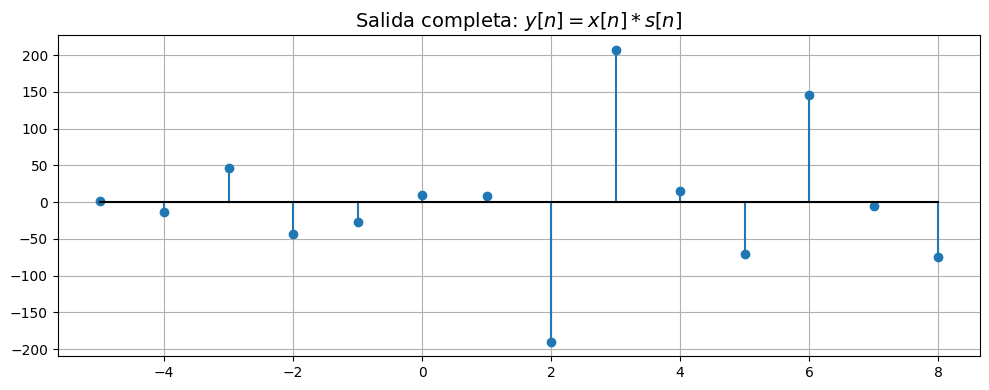

interactive(children=(IntSlider(value=0, description='k', max=13), Output()), _dom_classes=('widget-interact',…

In [21]:
# BLOQUE H: Visualización respuesta escalón
movs_step, salida_step, s_final = convolucion_escalon(respuesta_escalon, entrada)

# Índice de n=0 en x[n] y s[n]
n0_x = 2
n0_s = 3
n0_y_step = n0_x + n0_s  # índice de n=0 en la convolución y[n]

# Eje de tiempo asociado a la salida
n_y_step = np.arange(-n0_y_step, len(salida_step) - n0_y_step)

# Mostrar resultados numéricos
print("Salida completa de la convolución con respuesta al escalón s[n]:\n")
for n_val, y_val in zip(n_y_step, salida_step):
    print(f"n = {n_val:>2} --> y[n] = {y_val:>6.1f}")

# Graficar la salida completa
plt.figure(figsize=(10, 4))
# Remove the 'use_line_collection=True' argument as it's deprecated in newer matplotlib versions
plt.stem(n_y_step, salida_step, basefmt='k')
plt.title('Salida completa: $y[n] = x[n] * s[n]$', fontsize=14)

plt.grid(True)
plt.tight_layout()
plt.show()

def mostrar_etapas_escalon(k, x_mov, y, r):
    plt.figure(figsize=(10, 4))
    plt.stem(x_mov[:, k], markerfmt='^', linefmt='b-', label='Entrada x[k]')
    plt.stem(r, markerfmt='o', linefmt='g-', label='Respuesta s[n-k]')
    plt.stem(y[:k+1], markerfmt='s', linefmt='r-', label='Salida parcial y[n]')
    plt.title('Convolución con respuesta al escalón')
    plt.xlabel('n')
    plt.ylabel('Amplitud')
    plt.grid(True)
    plt.legend()
    plt.show()

@interact(k=(0, len(salida_step)-1))
def interactividad(k=0):
    mostrar_etapas_escalon(k, movs_step, salida_step, s_final)


Salida con respuesta al escalón s[n]:
n = -5 --> y[n] =    1.0
n = -4 --> y[n] =  -13.0
n = -3 --> y[n] =   47.0
n = -2 --> y[n] =  -43.0
n = -1 --> y[n] =  -27.0
n =  0 --> y[n] =    9.0
n =  1 --> y[n] =    8.0
n =  2 --> y[n] = -190.0
n =  3 --> y[n] =  207.0
n =  4 --> y[n] =   15.0
n =  5 --> y[n] =  -71.0
n =  6 --> y[n] =  145.0
n =  7 --> y[n] =   -5.0
n =  8 --> y[n] =  -75.0


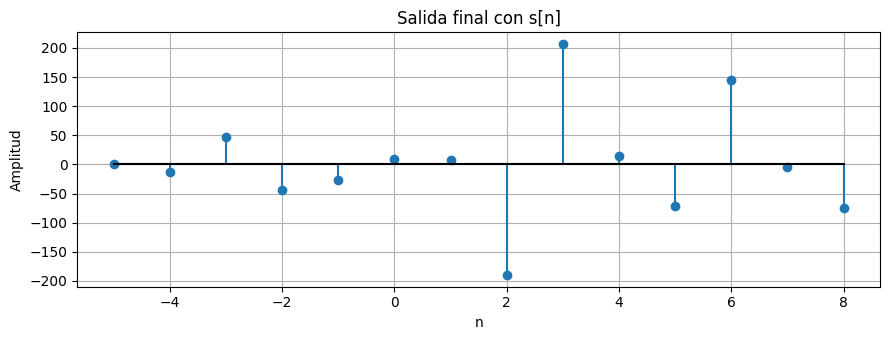

In [22]:
# BLOQUE I: Resultado final con s[n]
n0_s = 3
n0_total = pos_cero_x + n0_s
eje_salida = np.arange(-n0_total, len(salida_step) - n0_total)

print("\nSalida con respuesta al escalón s[n]:")
for n_idx, valor in zip(eje_salida, salida_step):
    print(f"n = {n_idx:>2} --> y[n] = {valor:>6.1f}")

# Gráfica final completa
plt.figure(figsize=(9, 3.5))
plt.stem(eje_salida, salida_step, basefmt='k')
plt.title('Salida final con s[n]')
plt.xlabel('n')
plt.ylabel('Amplitud')
plt.grid(True)
plt.tight_layout()
plt.show()
